<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/After%20School%20Programs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [227]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [228]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [229]:
#!python --version
gpd.__version__

'1.2.0'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

In [230]:
#Camden County Open Data Portal
#https://camdencountynj-ccdpw.opendata.arcgis.com/datasets/CCDPW::municipalities/about
#code used from class
! wget -q -O Municipalities.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Municipalities.zip

zip_ref = zipfile.ZipFile('Municipalities.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njMun=gpd.read_file('Municipalities.shp') #labeled shapefile njMun
#Camden County Municipal shapefile better use than NJ school district shapefile

<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

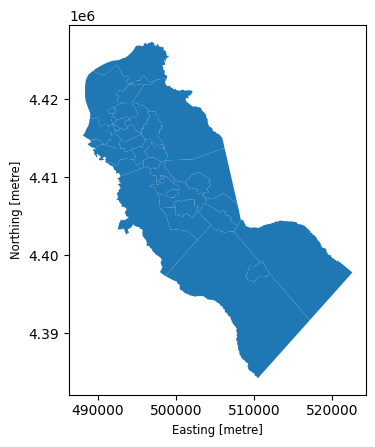

In [231]:
njMun.plot()

In [232]:
#identify headings of shapefile
njMun.head(2)

,FID,COUSUBNS,GEOID,NAMELSAD,CLASSFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,GEOCODE,GlobalID,Shape__Are,Shape__Len,geometry
0,1,00885144,3400702200,Audubon borough,C5,F,3838781,35535,+39.8901277,-75.0723825,9407.757950,3400702200,81d661c6-35a7-42ed-8afd-5f35d0b0e807,3.871214e+06,9407.757866,"POLYGON ((495599.23 4415536.249, 495508.749 44..."
1,2,00885145,3400702230,Audubon Park borough,C5,F,389606,46935,+39.8968373,-75.0888190,2734.677596,3400702230,f8ccbea8-76dd-44e7-992b-e367d22e31a1,4.361934e+05,2734.677499,"POLYGON ((492866.221 4416337.872, 492855.687 4..."


In [233]:
#Rename field, make renamed column upper case and select only items w/ GEO data
njMun.rename(columns={'NAMELSAD' : 'Muni'}, inplace=True)
njMun['Muni'] = njMun['Muni'].str.upper()
njMun.loc[njMun['Muni'] == 'GLOUCESTER CITY CITY','Muni'] = 'GLOUCESTER CITY'
njMun1 = njMun[['Muni','GEOID', 'geometry']]
njMun1

,Muni,GEOID,geometry
0,AUDUBON BOROUGH,3400702200,"POLYGON ((495599.23 4415536.249, 495508.749 44..."
1,AUDUBON PARK BOROUGH,3400702230,"POLYGON ((492866.221 4416337.872, 492855.687 4..."
2,BARRINGTON BOROUGH,3400703250,"POLYGON ((496819.374 4414558.505, 496827.878 4..."
3,BELLMAWR BOROUGH,3400704750,"POLYGON ((492951.896 4413667.751, 492968.147 4..."
4,BERLIN BOROUGH,3400705440,"POLYGON ((507881.319 4403761.193, 507873.371 4..."
5,BERLIN TOWNSHIP,3400705470,"POLYGON ((507848.567 4406644.366, 507978.687 4..."
6,BROOKLAWN BOROUGH,3400708170,"POLYGON ((490740.818 4414218.502, 490736.285 4..."
7,CAMDEN CITY,3400710000,"POLYGON ((493032.266 4419551.728, 492897.768 4..."
8,CHERRY HILL TOWNSHIP,3400712280,"POLYGON ((506224.674 4413748.279, 506174.32 44..."
9,CHESILHURST BOROUGH,3400712550,"POLYGON ((512006.451 4397643.342, 512016.246 4..."


In [234]:
DisXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Economically%20Disadvantage%20Youth.xlsx', header = 3)

In [235]:
DisXls1=DisXls[DisXls['SchoolYear'] =='2024-25'][['CountyName','DistrictCode','DistrictName','Economically Disadvantaged Students']]
DisXls1.rename(columns={'DistrictName' : 'District'}, inplace=True)
DisXls1['District'] = DisXls1['District'].str.upper()
DisXls1

,CountyName,DistrictCode,District,Economically Disadvantaged Students
4,Camden,150,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%
9,Camden,190,BARRINGTON SCHOOL DISTRICT,34.1%
14,Camden,260,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%
19,Camden,330,BERLIN BOROUGH SCHOOL DISTRICT,25.2%
24,Camden,340,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%
29,Camden,390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%
34,Camden,580,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%
39,Camden,680,CAMDEN CITY SCHOOL DISTRICT,88.5%
44,Camden,700,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,56.1%
49,Camden,800,CHERRY HILL SCHOOL DISTRICT,23.2%


In [236]:
#njMun1[['MUN','GEOID']]
#code from class to strip white space for merging
DisXls1['District']=DisXls1.District.str.strip()
njMun1['District']=njMun1.Muni.str.strip()

/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:2011: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [237]:
#code from Gemini to make all upper case for merging
DisXls1['District'] = DisXls1['District'].str.upper()
njMun1['District'] = njMun1['District'].str.upper()
njMun1['first_word_District'] = njMun1['District'].str.split().str[0]

/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:2011: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [238]:
njMun['first_word_Muni'] = njMun['Muni'].str.split().str[0]
DisXls1['first_word_District'] = DisXls1['District'].str.split().str[0]

In [239]:
#merged newly created column "first_word_MUN", MUN and Camden County
a6 = pd.merge(njMun1, DisXls1, left_on=['first_word_District'], right_on=['first_word_District'], how='outer', indicator=True)
a6

,Muni,GEOID,geometry,District_x,first_word_District,CountyName,DistrictCode,District_y,Economically Disadvantaged Students,_merge
0,AUDUBON BOROUGH,3400702200,"POLYGON ((495599.23 4415536.249, 495508.749 44...",AUDUBON BOROUGH,AUDUBON,Camden,150.0,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%,both
1,AUDUBON PARK BOROUGH,3400702230,"POLYGON ((492866.221 4416337.872, 492855.687 4...",AUDUBON PARK BOROUGH,AUDUBON,Camden,150.0,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%,both
2,BARRINGTON BOROUGH,3400703250,"POLYGON ((496819.374 4414558.505, 496827.878 4...",BARRINGTON BOROUGH,BARRINGTON,Camden,190.0,BARRINGTON SCHOOL DISTRICT,34.1%,both
3,BELLMAWR BOROUGH,3400704750,"POLYGON ((492951.896 4413667.751, 492968.147 4...",BELLMAWR BOROUGH,BELLMAWR,Camden,260.0,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%,both
4,BERLIN BOROUGH,3400705440,"POLYGON ((507881.319 4403761.193, 507873.371 4...",BERLIN BOROUGH,BERLIN,Camden,330.0,BERLIN BOROUGH SCHOOL DISTRICT,25.2%,both
5,BERLIN BOROUGH,3400705440,"POLYGON ((507881.319 4403761.193, 507873.371 4...",BERLIN BOROUGH,BERLIN,Camden,340.0,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%,both
6,BERLIN TOWNSHIP,3400705470,"POLYGON ((507848.567 4406644.366, 507978.687 4...",BERLIN TOWNSHIP,BERLIN,Camden,330.0,BERLIN BOROUGH SCHOOL DISTRICT,25.2%,both
7,BERLIN TOWNSHIP,3400705470,"POLYGON ((507848.567 4406644.366, 507978.687 4...",BERLIN TOWNSHIP,BERLIN,Camden,340.0,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%,both
8,NaN,NaN,None,NaN,BLACK,Camden,390.0,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%,right_only
9,BROOKLAWN BOROUGH,3400708170,"POLYGON ((490740.818 4414218.502, 490736.285 4...",BROOKLAWN BOROUGH,BROOKLAWN,Camden,580.0,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%,both


In [240]:
a6._merge.value_counts()

,count
_merge,
both,41
right_only,8
left_only,3


<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

Text(0.5, 1.0, '% of Economically Disadvantaged Students\n2024 - 2025 School Year')

Text(0.35, 0.122, 'New Jersey, Department of Education\n            2024 - 2025 Performance Reports Database - Excel\n            Data from https://www.nj.gov/education/spr/download/\n            ')

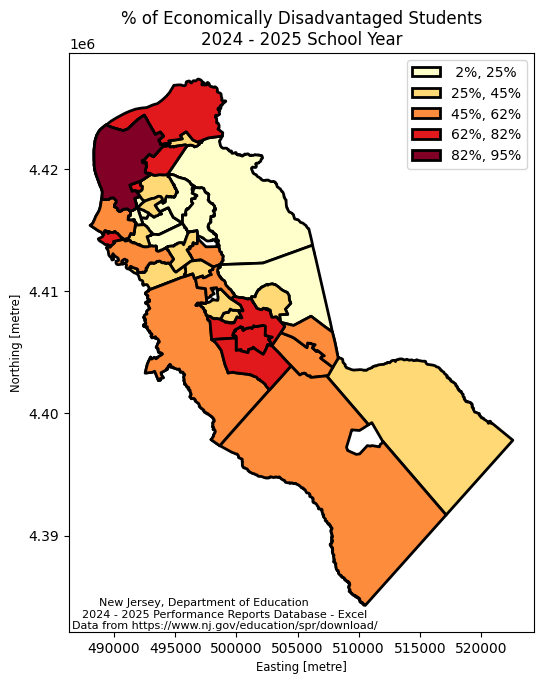

In [241]:
fig, ax = plt.subplots(figsize=(6,8))

# Convert the 'Economically Disadvantaged Students' column to numeric, handling NaN values
a6['Economically Disadvantaged Students'] = a6['Economically Disadvantaged Students'].apply(lambda x: float(x.replace('%', '')) if isinstance(x, str) else x)

a6.plot(ax=ax,figsize=(6,8),column='Economically Disadvantaged Students',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}%"})
ax.set_title('''% of Economically Disadvantaged Students
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''New Jersey, Department of Education
            2024 - 2025 Performance Reports Database - Excel
            Data from https://www.nj.gov/education/spr/download/
            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

In [242]:
#in-school incidents involving violence, weapons, substance abuse and vandalism
BehXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/School%20Incidents.xlsx', header = 3)

In [243]:
BehXls.head(3)

,CountyCode,CountyName,DistrictCode,DistrictName,SchoolYear,Violence,Weapons,Vandalism,Substances,HIB,TotalUniqueIncidents,IncidentsPer100Students
0,01,Atlantic,0010,Absecon Public Schools District,2024-25,1.0,0.0,0.0,0.0,5.0,6.0,0.64
1,01,Atlantic,0110,Atlantic City School District,2024-25,130.0,12.0,4.0,36.0,22.0,204.0,3.17
2,01,Atlantic,0120,Atlantic County Vocational School District,2024-25,2.0,0.0,2.0,10.0,2.0,16.0,0.89


In [244]:
BehXls.rename(columns={'DistrictName': 'Muni'}, inplace=True)
BehXls['Muni'] = BehXls['Muni'].str.upper()
BehXls.loc[BehXls['Muni'] == 'MT. EPHRAIM SCHOOL DISTRICT','Muni'] = 'MOUNT EPHRAIM SCHOOL DISTRICT'
BehXls

,CountyCode,CountyName,DistrictCode,Muni,SchoolYear,Violence,Weapons,Vandalism,Substances,HIB,TotalUniqueIncidents,IncidentsPer100Students
0,01,Atlantic,0010,ABSECON PUBLIC SCHOOLS DISTRICT,2024-25,1.0,0.0,0.0,0.0,5.0,6.0,0.64
1,01,Atlantic,0110,ATLANTIC CITY SCHOOL DISTRICT,2024-25,130.0,12.0,4.0,36.0,22.0,204.0,3.17
2,01,Atlantic,0120,ATLANTIC COUNTY VOCATIONAL SCHOOL DISTRICT,2024-25,2.0,0.0,2.0,10.0,2.0,16.0,0.89
3,01,Atlantic,0125,ATLANTIC COUNTY SPECIAL SERVICES SCHOOL DISTRICT,2024-25,2.0,0.0,0.0,0.0,4.0,6.0,1.72
4,01,Atlantic,0570,BRIGANTINE PUBLIC SCHOOL DISTRICT,2024-25,0.0,0.0,0.0,0.0,2.0,2.0,0.53
...,...,...,...,...,...,...,...,...,...,...,...,...
663,80,Morris,8050,UNITY CHARTER SCHOOL,2024-25,0.0,0.0,0.0,0.0,0.0,0.0,0.00
664,80,Hudson,8060,UNIVERSITY ACADEMY CHARTER HIGH SCHOOL,2024-25,23.0,2.0,2.0,7.0,0.0,34.0,8.15
665,80,Mercer,8140,THE VILLAGE CHARTER SCHOOL,2024-25,11.0,0.0,0.0,3.0,2.0,16.0,4.40
666,State,State,State,STATE,2024-25,12730.0,902.0,1793.0,7198.0,7456.0,29826.0,2.13


In [245]:
# Filter for both only to show 2024-2025 SchoolYear and Camden
BehXls1 = BehXls[(BehXls['SchoolYear'] == '2024-25') & (BehXls['CountyName'] == 'Camden')][['DistrictCode', 'Muni', 'IncidentsPer100Students']]
BehXls1

,DistrictCode,Muni,IncidentsPer100Students
139,0150,AUDUBON PUBLIC SCHOOL DISTRICT,1.27
140,0190,BARRINGTON SCHOOL DISTRICT,0.38
141,0260,BELLMAWR PUBLIC SCHOOL DISTRICT,0.17
142,0330,BERLIN BOROUGH SCHOOL DISTRICT,1.99
143,0340,BERLIN TOWNSHIP SCHOOL DISTRICT,1.94
144,0390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,3.35
145,0580,BROOKLAWN PUBLIC SCHOOL DISTRICT,1.72
146,0680,CAMDEN CITY SCHOOL DISTRICT,4.33
147,0700,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,2.80
148,0800,CHERRY HILL SCHOOL DISTRICT,1.62


In [246]:
#njMun1[['MUN','GEOID']]
#code from class to strip white space for merging
BehXls1['Muni']=BehXls1.Muni.str.strip()

In [247]:
BehXls1['first_word_Muni'] = BehXls1['Muni'].str.split().str[0]

In [248]:
#merged newly created column "first_word_MUN", MUN and Camden County
a1 = pd.merge(njMun, BehXls1, left_on=['first_word_Muni'], right_on=['first_word_Muni'], how='outer', indicator=True)
a1

,FID,COUSUBNS,GEOID,Muni_x,CLASSFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,...,GEOCODE,GlobalID,Shape__Are,Shape__Len,geometry,first_word_Muni,DistrictCode,Muni_y,IncidentsPer100Students,_merge
0,1.0,00885144,3400702200,AUDUBON BOROUGH,C5,F,3838781.0,35535.0,+39.8901277,-75.0723825,...,3.400702e+09,81d661c6-35a7-42ed-8afd-5f35d0b0e807,3.871214e+06,9407.757866,"POLYGON ((495599.23 4415536.249, 495508.749 44...",AUDUBON,0150,AUDUBON PUBLIC SCHOOL DISTRICT,1.27,both
1,2.0,00885145,3400702230,AUDUBON PARK BOROUGH,C5,F,389606.0,46935.0,+39.8968373,-75.0888190,...,3.400702e+09,f8ccbea8-76dd-44e7-992b-e367d22e31a1,4.361934e+05,2734.677499,"POLYGON ((492866.221 4416337.872, 492855.687 4...",AUDUBON,0150,AUDUBON PUBLIC SCHOOL DISTRICT,1.27,both
2,3.0,00885149,3400703250,BARRINGTON BOROUGH,C5,F,4095340.0,0.0,+39.8689349,-75.0513618,...,3.400703e+09,9e9086b1-16e4-429f-b5c4-d967de1dbd82,4.092067e+06,11456.984073,"POLYGON ((496819.374 4414558.505, 496827.878 4...",BARRINGTON,0190,BARRINGTON SCHOOL DISTRICT,0.38,both
3,4.0,00885154,3400704750,BELLMAWR BOROUGH,C5,F,7729295.0,315734.0,+39.8663560,-75.0946695,...,3.400705e+09,bdd07346-3ee8-471e-befd-b8b9e16eb0a9,8.038608e+06,18085.472003,"POLYGON ((492951.896 4413667.751, 492968.147 4...",BELLMAWR,0260,BELLMAWR PUBLIC SCHOOL DISTRICT,0.17,both
4,5.0,00885158,3400705440,BERLIN BOROUGH,C5,F,9307767.0,35573.0,+39.7920594,-74.9369855,...,3.400705e+09,032f4608-e579-4343-a5e1-7d3778ce56c5,9.335884e+06,14823.777540,"POLYGON ((507881.319 4403761.193, 507873.371 4...",BERLIN,0330,BERLIN BOROUGH SCHOOL DISTRICT,1.99,both
5,5.0,00885158,3400705440,BERLIN BOROUGH,C5,F,9307767.0,35573.0,+39.7920594,-74.9369855,...,3.400705e+09,032f4608-e579-4343-a5e1-7d3778ce56c5,9.335884e+06,14823.777540,"POLYGON ((507881.319 4403761.193, 507873.371 4...",BERLIN,0340,BERLIN TOWNSHIP SCHOOL DISTRICT,1.94,both
6,6.0,00882152,3400705470,BERLIN TOWNSHIP,T1,A,8656740.0,15360.0,+39.8071159,-74.9241780,...,3.400705e+09,e17a4101-16d7-4093-b9da-43f1044ceef7,8.665170e+06,15771.555122,"POLYGON ((507848.567 4406644.366, 507978.687 4...",BERLIN,0330,BERLIN BOROUGH SCHOOL DISTRICT,1.99,both
7,6.0,00882152,3400705470,BERLIN TOWNSHIP,T1,A,8656740.0,15360.0,+39.8071159,-74.9241780,...,3.400705e+09,e17a4101-16d7-4093-b9da-43f1044ceef7,8.665170e+06,15771.555122,"POLYGON ((507848.567 4406644.366, 507978.687 4...",BERLIN,0340,BERLIN TOWNSHIP SCHOOL DISTRICT,1.94,both
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,BLACK,0390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,3.35,right_only
9,7.0,00885172,3400708170,BROOKLAWN BOROUGH,C5,F,1265110.0,105763.0,+39.8793503,-75.1203958,...,3.400708e+09,1e1a2ee3-3807-458d-8af0-7a2d5df7de30,1.369780e+06,5697.800436,"POLYGON ((490740.818 4414218.502, 490736.285 4...",BROOKLAWN,0580,BROOKLAWN PUBLIC SCHOOL DISTRICT,1.72,both


In [249]:
a1._merge.value_counts()

,count
_merge,
both,41
right_only,8
left_only,3


<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

Text(0.5, 1.0, '% of Incidents Per 100 Students\n2024 - 2025 School Year')

Text(0.35, 0.122, 'New Jersey, Department of Education\n            2024 - 2025 Performance Reports Database - Excel\n            Data from https://www.nj.gov/education/spr/download/\n            ')

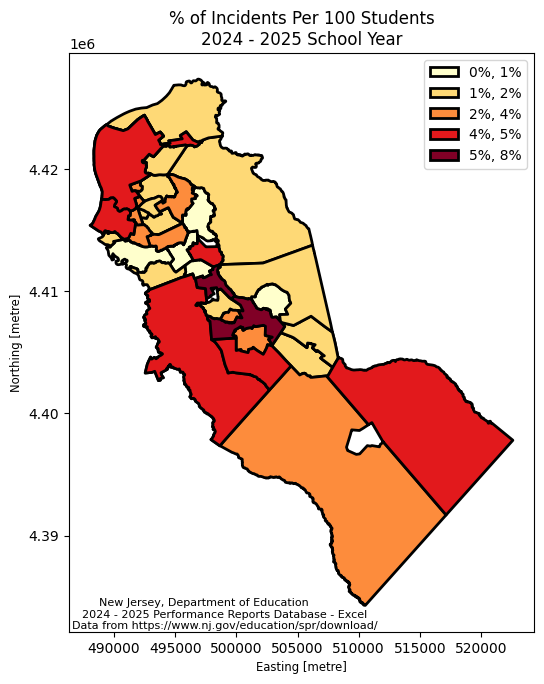

In [250]:
fig, ax = plt.subplots(figsize=(6,8))

# Convert the 'Economically Disadvantaged Students' column to numeric, handling NaN values
a1['IncidentsPer100Students'] = a1['IncidentsPer100Students'].apply(lambda x: float(x.replace('%', '')) if isinstance(x, str) else x)

a1.plot(ax=ax,figsize=(6,8),column='IncidentsPer100Students',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}%"})
ax.set_title('''% of Incidents Per 100 Students
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''New Jersey, Department of Education
            2024 - 2025 Performance Reports Database - Excel
            Data from https://www.nj.gov/education/spr/download/
            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

In [251]:
EnrXls = pd.read_excel('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Camden%20County%20School%20Enrollment%20by%20School%20Level%202024%20-%20Public%20School%20Only.xlsx')

In [252]:
EnrXls.head(7)

,,"Audubon borough, Camden County, New Jersey","Audubon Park borough, Camden County, New Jersey","Barrington borough, Camden County, New Jersey","Bellmawr borough, Camden County, New Jersey","Berlin borough, Camden County, New Jersey","Berlin township, Camden County, New Jersey","Brooklawn borough, Camden County, New Jersey","Camden city, Camden County, New Jersey","Cherry Hill township, Camden County, New Jersey",...,"Pennsauken township, Camden County, New Jersey","Pine Hill borough, Camden County, New Jersey","Runnemede borough, Camden County, New Jersey","Somerdale borough, Camden County, New Jersey","Stratford borough, Camden County, New Jersey","Tavistock borough, Camden County, New Jersey","Voorhees township, Camden County, New Jersey","Waterford township, Camden County, New Jersey","Winslow township, Camden County, New Jersey","Woodlynne borough, Camden County, New Jersey"
0,Pre-School,90,0,11,128,26,26,4,987,332,...,298,250,100,93,32,0,67,199,118,10
1,K-8,767,50,277,1296,917,509,145,8628,7492,...,3725,855,601,366,673,2,3439,1029,3284,408
2,9-12,265,36,262,483,527,219,59,4221,2957,...,1869,463,326,168,301,0,1632,281,2049,204


In [253]:
EnrXls = (EnrXls
  .rename(columns={EnrXls.columns[0]: 'School_Level'}) # Rename the first unnamed column
  .melt(
      id_vars=['School_Level'],
      var_name='Muni', # New column for district names
      value_name='Enrollment' # New column for enrollment values
  )
)

# Clean up district names (remove ', Camden County, New Jersey')
EnrXls['Muni'] = EnrXls['Muni'].str.replace(', Camden County, New Jersey', '', regex=False).str.strip()

# Convert 'Enrollment' to numeric, coercing errors to NaN
EnrXls['Enrollment'] = pd.to_numeric(EnrXls['Enrollment'], errors='coerce')

In [254]:
EnrXls

,School_Level,Muni,Enrollment
0,Pre-School,Audubon borough,90
1,K-8,Audubon borough,767
2,9-12,Audubon borough,265
3,Pre-School,Audubon Park borough,0
4,K-8,Audubon Park borough,50
...,...,...,...
100,K-8,Winslow township,3284
101,9-12,Winslow township,2049
102,Pre-School,Woodlynne borough,10
103,K-8,Woodlynne borough,408


In [255]:
EnrXls['Muni'] = EnrXls['Muni'].str.upper()

In [256]:
enr9_12=EnrXls[EnrXls.School_Level.str.strip()=='9-12'] #aok: keep it simple for now
enr9_12.loc[enr9_12['Muni'] == 'GLOUCESTER CITY CITY','Muni'] = 'GLOUCESTER CITY'
enr9_12

,School_Level,Muni,Enrollment
2,9-12,AUDUBON BOROUGH,265
5,9-12,AUDUBON PARK BOROUGH,36
8,9-12,BARRINGTON BOROUGH,262
11,9-12,BELLMAWR BOROUGH,483
14,9-12,BERLIN BOROUGH,527
17,9-12,BERLIN TOWNSHIP,219
20,9-12,BROOKLAWN BOROUGH,59
23,9-12,CAMDEN CITY,4221
26,9-12,CHERRY HILL TOWNSHIP,2957
29,9-12,CHESILHURST BOROUGH,41


In [257]:
a2 = pd.merge(njMun1, enr9_12, on='Muni', how='outer', indicator=True)
a2.columns
# Displaying key columns to inspect the merged dataset
a2[['Muni', 'GEOID', 'School_Level', 'Enrollment', '_merge']]

Index(['Muni', 'GEOID', 'geometry', 'District', 'first_word_District',
       'School_Level', 'Enrollment', '_merge'],
      dtype='object')

,Muni,GEOID,School_Level,Enrollment,_merge
0,AUDUBON BOROUGH,3400702200,9-12,265.0,both
1,AUDUBON PARK BOROUGH,3400702230,9-12,36.0,both
2,BARRINGTON BOROUGH,3400703250,9-12,262.0,both
3,BELLMAWR BOROUGH,3400704750,9-12,483.0,both
4,BERLIN BOROUGH,3400705440,9-12,527.0,both
5,BERLIN TOWNSHIP,3400705470,9-12,219.0,both
6,BROOKLAWN BOROUGH,3400708170,9-12,59.0,both
7,CAMDEN CITY,3400710000,9-12,4221.0,both
8,CHERRY HILL TOWNSHIP,3400712280,9-12,2957.0,both
9,CHESILHURST BOROUGH,3400712550,9-12,41.0,both


In [258]:
a2._merge.value_counts()
#No high school info for Mount Eprhaim on this spreadsheet

,count
_merge,
both,35
left_only,1
right_only,0


<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

Text(0.5, 1.0, 'Total Students Enrolled in Public School\n2024 - 2025 School Year')

Text(0.35, 0.122, 'US Census: American Community Survey 5 Year\n            Downloaded Excel via:Shaperfile\n\n            ')

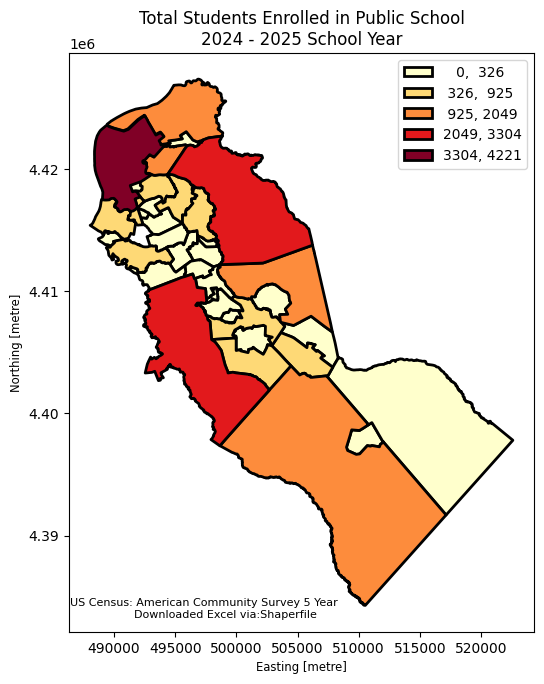

In [259]:
fig, ax = plt.subplots(figsize=(6,8))

a2.plot(ax=ax,figsize=(6,8),column='Enrollment',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}"})
ax.set_title('''Total Students Enrolled in Public School
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''US Census: American Community Survey 5 Year
            Downloaded Excel via:Shaperfile

            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

In [260]:
#Social Explorer; U.S. Census Bureau. Median Household Income (In 2024 Inflation Adjusted Dollars), 2024. Prepared by Social Explorer. https://www.socialexplorer.com/data/ACS2024_5yr/metadata?ds=SE&table=A14006 (accessed 27 September 2026 at 10:01:00 GMT-4).
IncXls = pd.read_excel('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Median%20Household%20Income.xlsx', header=3, nrows=36)

In [261]:
IncXls.head()

,SE:A14006:Median Household Income (In 2024 Inflation Adjusted Dollars),Unnamed: 1
0,"Audubon borough, Camden County, New Jersey",115789
1,"Audubon Park borough, Camden County, New Jersey",56619
2,"Barrington borough, Camden County, New Jersey",87290
3,"Bellmawr borough, Camden County, New Jersey",76654
4,"Berlin borough, Camden County, New Jersey",102855


In [262]:
IncXls1=IncXls[['SE:A14006:Median Household Income (In 2024 Inflation Adjusted Dollars)','Unnamed: 1']]
IncXls1.rename(columns={'SE:A14006:Median Household Income (In 2024 Inflation Adjusted Dollars)': 'Muni'}, inplace=True)
IncXls1.rename(columns={'Unnamed: 1': 'Median Income'}, inplace=True)
IncXls1['Muni'] = IncXls1['Muni'].str.upper()
IncXls1['Muni'] = IncXls1['Muni'].str.replace(', CAMDEN COUNTY, NEW JERSEY', '', regex=False).str.strip()
IncXls1

,Muni,Median Income
0,AUDUBON BOROUGH,115789
1,AUDUBON PARK BOROUGH,56619
2,BARRINGTON BOROUGH,87290
3,BELLMAWR BOROUGH,76654
4,BERLIN BOROUGH,102855
5,BERLIN TOWNSHIP,75238
6,BROOKLAWN BOROUGH,59063
7,CAMDEN CITY,40546
8,CHERRY HILL TOWNSHIP,121502
9,CHESILHURST BOROUGH,91683


In [263]:
IncXls1.loc[IncXls1['Muni'] == 'GLOUCESTER CITY CITY','Muni'] = 'GLOUCESTER CITY'
IncXls1

,Muni,Median Income
0,AUDUBON BOROUGH,115789
1,AUDUBON PARK BOROUGH,56619
2,BARRINGTON BOROUGH,87290
3,BELLMAWR BOROUGH,76654
4,BERLIN BOROUGH,102855
5,BERLIN TOWNSHIP,75238
6,BROOKLAWN BOROUGH,59063
7,CAMDEN CITY,40546
8,CHERRY HILL TOWNSHIP,121502
9,CHESILHURST BOROUGH,91683


In [264]:
a3 = pd.merge(njMun, IncXls1, on='Muni', how='outer', indicator=True)
a3

,FID,COUSUBNS,GEOID,Muni,CLASSFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,GEOCODE,GlobalID,Shape__Are,Shape__Len,geometry,first_word_Muni,Median Income,_merge
0,1,00885144,3400702200,AUDUBON BOROUGH,C5,F,3838781,35535,+39.8901277,-75.0723825,9407.757950,3400702200,81d661c6-35a7-42ed-8afd-5f35d0b0e807,3.871214e+06,9407.757866,"POLYGON ((495599.23 4415536.249, 495508.749 44...",AUDUBON,115789,both
1,2,00885145,3400702230,AUDUBON PARK BOROUGH,C5,F,389606,46935,+39.8968373,-75.0888190,2734.677596,3400702230,f8ccbea8-76dd-44e7-992b-e367d22e31a1,4.361934e+05,2734.677499,"POLYGON ((492866.221 4416337.872, 492855.687 4...",AUDUBON,56619,both
2,3,00885149,3400703250,BARRINGTON BOROUGH,C5,F,4095340,0,+39.8689349,-75.0513618,11456.984021,3400703250,9e9086b1-16e4-429f-b5c4-d967de1dbd82,4.092067e+06,11456.984073,"POLYGON ((496819.374 4414558.505, 496827.878 4...",BARRINGTON,87290,both
3,4,00885154,3400704750,BELLMAWR BOROUGH,C5,F,7729295,315734,+39.8663560,-75.0946695,18085.471872,3400704750,bdd07346-3ee8-471e-befd-b8b9e16eb0a9,8.038608e+06,18085.472003,"POLYGON ((492951.896 4413667.751, 492968.147 4...",BELLMAWR,76654,both
4,5,00885158,3400705440,BERLIN BOROUGH,C5,F,9307767,35573,+39.7920594,-74.9369855,14823.777678,3400705440,032f4608-e579-4343-a5e1-7d3778ce56c5,9.335884e+06,14823.777540,"POLYGON ((507881.319 4403761.193, 507873.371 4...",BERLIN,102855,both
5,6,00882152,3400705470,BERLIN TOWNSHIP,T1,A,8656740,15360,+39.8071159,-74.9241780,15771.555136,3400705470,e17a4101-16d7-4093-b9da-43f1044ceef7,8.665170e+06,15771.555122,"POLYGON ((507848.567 4406644.366, 507978.687 4...",BERLIN,75238,both
6,7,00885172,3400708170,BROOKLAWN BOROUGH,C5,F,1265110,105763,+39.8793503,-75.1203958,5697.800517,3400708170,1e1a2ee3-3807-458d-8af0-7a2d5df7de30,1.369780e+06,5697.800436,"POLYGON ((490740.818 4414218.502, 490736.285 4...",BROOKLAWN,59063,both
7,8,00885177,3400710000,CAMDEN CITY,C5,F,23106182,3676392,+39.9367868,-75.1066438,28004.054276,3400710000,f5c8c982-1593-4592-a38a-485a23bd7d98,2.676122e+07,28004.054367,"POLYGON ((493032.266 4419551.728, 492897.768 4...",CAMDEN,40546,both
8,9,00882155,3400712280,CHERRY HILL TOWNSHIP,T1,A,62346260,321495,+39.9046107,-74.9969997,42634.513569,3400712280,561f8439-f9d9-47af-a877-f4c81e30fd7a,6.261764e+07,42634.513259,"POLYGON ((506224.674 4413748.279, 506174.32 44...",CHERRY,121502,both
9,10,00885183,3400712550,CHESILHURST BOROUGH,C5,F,4442825,4000,+39.7297952,-74.8805311,9002.409548,3400712550,db06a511-84e0-41f6-a5d9-e8afa47e852f,4.443282e+06,9002.409554,"POLYGON ((512006.451 4397643.342, 512016.246 4...",CHESILHURST,91683,both


In [265]:
a3._merge.value_counts()

,count
_merge,
both,36
left_only,0
right_only,0


<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

Text(0.5, 1.0, 'Median Household Income')

Text(0.35, 0.122, 'US Census: American Community Survey 5 Year\n            Downloaded Excel via:Shaperfile\n\n            ')

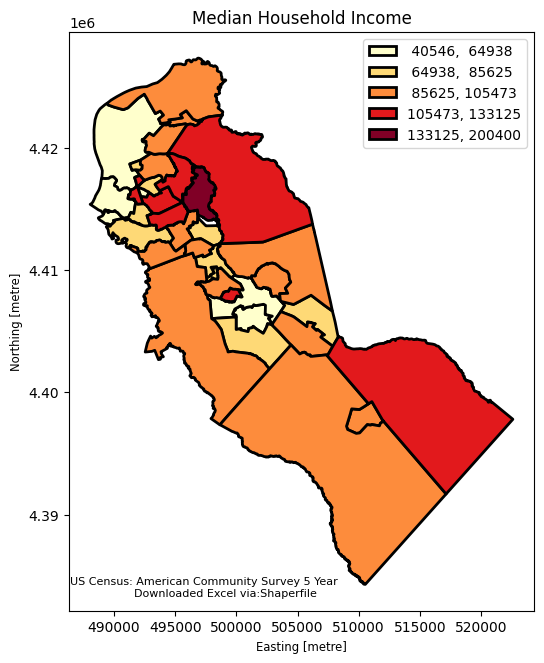

In [266]:
# Convert 'Median Income' to numeric, converting blank spaces to NaN so that mapclassify can sort and bin them
a3['Median Income'] = pd.to_numeric(a3['Median Income'], errors='coerce')

fig, ax = plt.subplots(figsize=(6,8))

a3.plot(ax=ax,figsize=(6,8),column='Median Income',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}"})
ax.set_title('''Median Household Income''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''US Census: American Community Survey 5 Year
            Downloaded Excel via:Shaperfile

            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

In [267]:
PrgXls = pd.read_excel('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/After%20School%20Programs.xlsx')

In [268]:
PrgXls.head()

,After School Programs,Address,City,Zip Code,Unnamed: 4,Points
0,William P Tatem Elementary,265 Lincoln Ave,Collingswood,8108.0,Health,"39.919830768279446, -75.06636836084603"
1,Thomas Sharp Elementary,400 Comly Ave.,Collingswood,8108.0,Health,"39.91187707083164, -75.08967254919715"
2,James A Garfield Elementary School,480 Haddon Ave,Collingswood,8108.0,Health,"39.918330042835734, -75.07577813201654"
3,Mark Newbie Elementary School,2 E. Browning Rd.,Collingswood,8108.0,Health,"39.920963350299246, -75.08050581851745"
4,Zane North Elementary School,801 Stokes Ave,Collingswood,8108.0,Health,"39.91218665283394, -75.06714461851787"


In [269]:
PrgXls = PrgXls.rename(columns={'Unnamed: 4': 'Prog Type'})
PrgXls

,After School Programs,Address,City,Zip Code,Prog Type,Points
0,William P Tatem Elementary,265 Lincoln Ave,Collingswood,8108.0,Health,"39.919830768279446, -75.06636836084603"
1,Thomas Sharp Elementary,400 Comly Ave.,Collingswood,8108.0,Health,"39.91187707083164, -75.08967254919715"
2,James A Garfield Elementary School,480 Haddon Ave,Collingswood,8108.0,Health,"39.918330042835734, -75.07577813201654"
3,Mark Newbie Elementary School,2 E. Browning Rd.,Collingswood,8108.0,Health,"39.920963350299246, -75.08050581851745"
4,Zane North Elementary School,801 Stokes Ave,Collingswood,8108.0,Health,"39.91218665283394, -75.06714461851787"
5,Collingswood Early Childhood Center,"201 Dayton Ave.,",Collingswood,8108.0,Health,"39.913541613333095, -75.06978653201057"
6,Parkview Preschool,700 W. Browning Rd,Collingswood,8107.0,Health,"39.91090573180319, -75.08175217618947"
7,Oaklyn Public School,136 Kendall Blvd,Oaklyn,8107.0,Health,"39.90024362536255, -75.08405891851841"
8,NaN,NaN,NaN,NaN,NaN,NaN
9,"After-School All-Stars, Copewood Campus",1650 Copewood St,Camden,8103.0,General,"39.92518503322866, -75.09381755397084"


In [270]:
PrgFsc = PrgXls[PrgXls['Prog Type'].str.strip() == 'Family Success Center']
PrgFsc = PrgFsc.rename(columns={'Points': 'geometry'})
PrgFsc

,After School Programs,Address,City,Zip Code,Prog Type,geometry
25,Evolution Family Success Center,2850 Federal St,Camden,8105.0,Family Success Center,"39.946700380136654, -75.08307717609334"
26,Promise Neighborhood,580 Benson St,Camden,8103.0,Family Success Center,"39.94073398852416, -75.11809200678054"
27,Building Bridges Family Success Center,717 Chews Landing Rd,Clementon,8021.0,Family Success Center,"39.81315998317219, -75.01977497116454"
28,Orchards Family Success Center,"416 Sicklerville Rd., Unit A-2",Sicklerville,8081.0,Family Success Center,"39.71956140595062, -74.97167451534193"


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

Text(0.5, 1.0, 'Family Success Center Locations in Camden County')

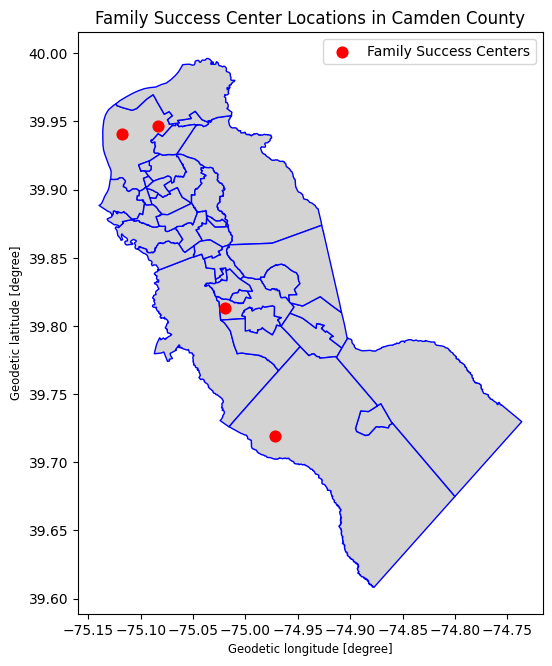

In [276]:
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

# Split coordinates into Latitude and Longitude (Note: points in 'geometry' are formatted as 'Lat, Lon')
coords = PrgFsc['geometry'].str.split(',', expand=True)
lat = pd.to_numeric(coords[0], errors='coerce')
lon = pd.to_numeric(coords[1], errors='coerce')

# Create a GeoDataFrame from the points using EPSG:4326 CRS (WGS84 lat/lon)
geometry_points = [Point(xy) for xy in zip(lon, lat)]
PrgFsc_gpd = gpd.GeoDataFrame(PrgFsc, geometry=geometry_points, crs="EPSG:4326")

# Ensure both GeoDataFrames use the same Coordinate Reference System (CRS) for mapping
njMun_gpd = njMun.to_crs(epsg=4326)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 8))
njMun_gpd.plot(ax=ax, color='lightlightgrey' if 'lightlightgrey' in plt.colormaps() else 'lightgrey', edgecolor='blue', linewidth=1)
PrgFsc_gpd.plot(ax=ax, color='red', marker='o', markersize=60, label='Family Success Centers')

plt.title('Family Success Center Locations in Camden County')
plt.legend()
plt.show()

In [272]:
PrgGen = PrgXls[PrgXls['Prog Type'].str.strip() == 'General']
PrgGen = PrgGen.rename(columns={'Points': 'geometry'})
PrgGen

,After School Programs,Address,City,Zip Code,Prog Type,geometry
9,"After-School All-Stars, Copewood Campus",1650 Copewood St,Camden,8103.0,General,"39.92518503322866, -75.09381755397084"
10,"After-School All-Stars, Mt. Ephraim Campus",1575 Mt. Ephraim Ave,Camden,8104.0,General,"39.925556236572525, -75.10586440556487"
11,Salcation Army Camden Kroc Center,1865 Harriaon Ave,Camden,8105.0,General,"39.955597438301226, -75.1014689806841"
12,LUCY Outreach,3201 Federal St.,Camden,8105.0,General,"39.94794239731574, -75.07613094920235"
13,Urban Promise,27 N. 36th St.,Camden,8105.0,General,"39.94877191997659, -75.07314543200899"
14,"Champions, Lindenwold School 1",550 Chews Landing Rd,Lindenwold,8021.0,General,"39.80997769848617, -75.01563883755058"
15,"Champions, Lindenwold School 4",900 E. Gibbsboro Rd,Lindenwold,8021.0,General,"39.82358609939801, -74.97700404919587"
16,"Champions, Lindenwold Early Childhood Ctr",801 Egg Harbor Rd,Lindenwold,8021.0,General,"39.82090962373621, -74.97568799337321"
17,Boys & Girls Club of Camden County,2 North Dudley St,Camden,8105.0,General,"39.94869392037658, -75.0807478166659"
18,Camden Y,"1 Market St, Ste 2D",Camden,8102.0,General,"39.94720362487922, -75.12735716084484"


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

Text(0.5, 1.0, 'Various After School Program Locations in Camden County')

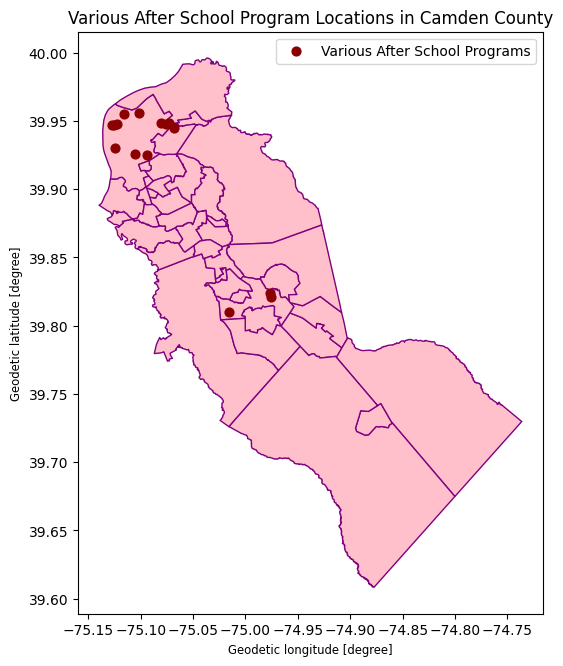

In [299]:
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

# Split coordinates into Latitude and Longitude (Note: points in 'geometry' are formatted as 'Lat, Lon')
coords = PrgGen['geometry'].str.split(',', expand=True)
lat = pd.to_numeric(coords[0], errors='coerce')
lon = pd.to_numeric(coords[1], errors='coerce')

# Create a GeoDataFrame from the points using EPSG:4326 CRS (WGS84 lat/lon)
geometry_points = [Point(xy) for xy in zip(lon, lat)]
PrgGen_gpd = gpd.GeoDataFrame(PrgGen, geometry=geometry_points, crs="EPSG:4326")

# Ensure both GeoDataFrames use the same Coordinate Reference System (CRS) for mapping
njMun_gpd = njMun.to_crs(epsg=4326)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 8))
njMun_gpd.plot(ax=ax, color='pink' if 'pink' in plt.colormaps() else 'pink', edgecolor='purple', linewidth=1)
PrgGen_gpd.plot(ax=ax, color='darkred', marker='o', markersize=40, label='Various After School Programs')

plt.title('Various After School Program Locations in Camden County')
plt.legend()
plt.show()

In [274]:
PrgHea = PrgXls[PrgXls['Prog Type'].str.strip() == 'Health']
PrgHea = PrgHea.rename(columns={'Points': 'geometry'})
PrgHea

,After School Programs,Address,City,Zip Code,Prog Type,geometry
0,William P Tatem Elementary,265 Lincoln Ave,Collingswood,8108.0,Health,"39.919830768279446, -75.06636836084603"
1,Thomas Sharp Elementary,400 Comly Ave.,Collingswood,8108.0,Health,"39.91187707083164, -75.08967254919715"
2,James A Garfield Elementary School,480 Haddon Ave,Collingswood,8108.0,Health,"39.918330042835734, -75.07577813201654"
3,Mark Newbie Elementary School,2 E. Browning Rd.,Collingswood,8108.0,Health,"39.920963350299246, -75.08050581851745"
4,Zane North Elementary School,801 Stokes Ave,Collingswood,8108.0,Health,"39.91218665283394, -75.06714461851787"
5,Collingswood Early Childhood Center,"201 Dayton Ave.,",Collingswood,8108.0,Health,"39.913541613333095, -75.06978653201057"
6,Parkview Preschool,700 W. Browning Rd,Collingswood,8107.0,Health,"39.91090573180319, -75.08175217618947"
7,Oaklyn Public School,136 Kendall Blvd,Oaklyn,8107.0,Health,"39.90024362536255, -75.08405891851841"


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

Text(0.5, 1.0, 'Healthy Kid Program Locations in Camden County')

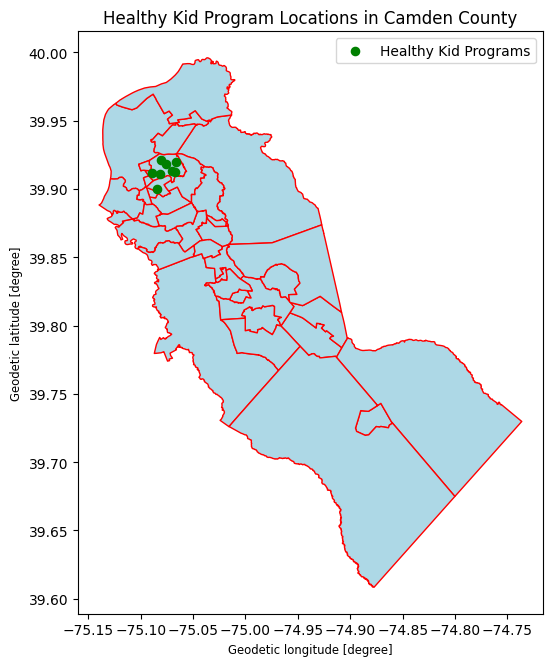

In [290]:
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

# Split coordinates into Latitude and Longitude (Note: points in 'geometry' are formatted as 'Lat, Lon')
coords = PrgHea['geometry'].str.split(',', expand=True)
lat = pd.to_numeric(coords[0], errors='coerce')
lon = pd.to_numeric(coords[1], errors='coerce')

# Create a GeoDataFrame from the points using EPSG:4326 CRS (WGS84 lat/lon)
geometry_points = [Point(xy) for xy in zip(lon, lat)]
PrgHea_gpd = gpd.GeoDataFrame(PrgHea, geometry=geometry_points, crs="EPSG:4326")

# Ensure both GeoDataFrames use the same Coordinate Reference System (CRS) for mapping
njMun_gpd = njMun.to_crs(epsg=4326)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 8))
njMun_gpd.plot(ax=ax, color='lightlightblue' if 'lightlightblue' in plt.colormaps() else 'lightblue', edgecolor='red', linewidth=1)
PrgHea_gpd.plot(ax=ax, color='green', marker='o', markersize=35, label='Healthy Kid Programs')

plt.title('Healthy Kid Program Locations in Camden County')
plt.legend()
plt.show()